In [1]:
from google.colab import files
uploaded=files.upload()

Saving TCS_stock_action.csv to TCS_stock_action.csv
Saving TCS_stock_history.csv to TCS_stock_history.csv
Saving TCS_stock_info.csv to TCS_stock_info.csv


In [2]:
import pandas as pd
df=pd.read_csv(r'TCS_stock_history.csv')
print(df.head(100))


          Date       Open       High        Low      Close   Volume  \
0   2002-08-12  28.794172  29.742206  28.794172  29.519140   212976   
1   2002-08-13  29.556316  30.030333  28.905705  29.119476   153576   
2   2002-08-14  29.184536  29.184536  26.563503  27.111877   822776   
3   2002-08-15  27.111877  27.111877  27.111877  27.111877        0   
4   2002-08-16  26.972458  28.255089  26.582090  27.046812   811856   
..         ...        ...        ...        ...        ...      ...   
95  2002-12-23  39.966081  39.975376  38.107194  38.376732  1277744   
96  2002-12-24  38.478968  40.151967  38.339552  39.956783  1729840   
97  2002-12-25  39.956783  39.956783  39.956783  39.956783        0   
98  2002-12-26  40.263505  41.601904  39.594305  41.090710  2894448   
99  2002-12-27  41.378838  41.546137  39.993965  40.161266   956984   

    Dividends  Stock Splits  
0         0.0           0.0  
1         0.0           0.0  
2         0.0           0.0  
3         0.0           0.0

In [ ]:
print(df.columns)
print('\n\n',df.dtypes)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')


 Date            datetime64[ns]
Open                   float64
High                   float64
Low                    float64
Close                  float64
Volume                   int64
Dividends              float64
Stock Splits           float64
dtype: object


In [3]:
print(df.isnull().sum())
print('\n\n',df.duplicated().sum())

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


 0


In [3]:
print(df[df['Volume']==0])
print('\n\n',(df['Volume']==0).sum())#25 such days when no stocks were bought and sold or it didn't exchange hands..

            Date         Open         High          Low        Close  Volume  \
3     2002-08-15    27.111877    27.111877    27.111877    27.111877       0   
21    2002-09-10    30.439287    30.439287    30.439287    30.439287       0   
37    2002-10-02    27.334944    27.334944    27.334944    27.334944       0   
46    2002-10-15    28.208612    28.208612    28.208612    28.208612       0   
62    2002-11-06    27.390717    27.390717    27.390717    27.390717       0   
71    2002-11-19    28.487448    28.487448    28.487448    28.487448       0   
79    2002-11-29    31.824150    31.824150    31.824150    31.824150       0   
97    2002-12-25    39.956783    39.956783    39.956783    39.956783       0   
133   2003-02-13    35.235210    35.235210    35.235210    35.235210       0   
154   2003-03-14    31.173542    31.173542    31.173542    31.173542       0   
156   2003-03-18    31.080597    31.080597    31.080597    31.080597       0   
159   2003-03-21    31.768383    31.7683

In [30]:
print(df['Dividends'])
print('\n\n',(df['Dividends']!=0).sum())#only 70 instance of dividends given
print('\n\n',(df['Stock Splits']!=0).sum())#only three instance of stock split

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
4458    0.0
4459    0.0
4460    0.0
4461    0.0
4462    0.0
Name: Dividends, Length: 4463, dtype: float64


 70


 3


In [8]:
print((df['Close']-df['Open']).mean())
print((df['High']-df['Open']).mean())
print((df['High']-df['Low']).mean())
print((df['High']-df['Close']).mean())
print((df['Low']-df['Open']).mean())
print((df['Low']-df['Close']).mean())

-0.3988400392750243
9.738774731243826
20.02116316388488
10.13761477051885
-10.282388432641056
-9.883548393366032


      **Daily Flow of Stock**

1-stock value normally on closing is JUST LESS THAN OR EQUAL TO where it opened during a day...so it reaches where it began

2-stock value normally reaches at max 10 values above where it opened and nearly same when it closes for the day

3-the minimum value the stock drops in a day is 10 values lower than both at opening and when it closes

 So, The stock exhibits mean-reverting intraday behavior, where daily highs and lows are approximately symmetric around the opening price, while closing prices tend to remain close to the opening price

In [5]:
df['high_open']=df['High']-df['Open']
df['low_open']=df['Low']-df['Open']
df['high_low']=df['High']-df['Low']
df['close_open']=df['Close']-df['Open']

df[['high_open','low_open','high_low','close_open']].describe()

,high_open,low_open,high_low,close_open
count,4463.000000,4463.000000,4463.000000,4463.000000
mean,9.738775,-10.282388,20.021163,-0.398840
std,15.012848,14.912683,21.768259,17.135797
min,0.000000,-177.241127,0.000000,-136.582427
25%,1.327308,-12.661483,5.977653,-5.023454
50%,4.483570,-4.952365,12.823509,-0.263238
75%,11.579126,-1.672999,26.040666,4.492103
max,234.644693,0.000000,305.993129,164.398504


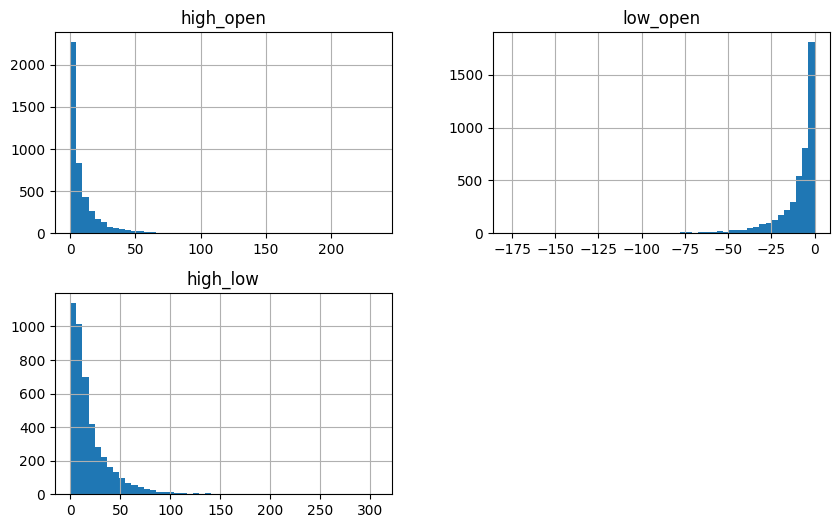

In [6]:
import matplotlib.pyplot as plt
df[['high_open','low_open','high_low']].hist(bins=50,figsize=(10,6))
plt.show()

In [ ]:
df['high_open'].nlargest(100)


,high_open
4083,234.644693
4089,136.466989
4078,128.752002
4084,127.630996
4443,125.149902
...,...
4135,54.107174
4098,53.948717
4123,53.899580
4198,53.784506


We can see that stock value that crossed the 100 value mark is in years 2020 and 21...so

In [ ]:
df[df['high_open']>12]#above 75%

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,daily_return,high_open,low_open,high_low
474,2005-07-18,117.430981,138.722381,117.430981,124.015366,14475608,0.0000,0.0,0.056070,21.291400,0.000000,21.291400
512,2005-09-12,134.342909,153.991382,132.227643,134.455719,6631072,0.0000,0.0,0.000840,19.648473,-2.115266,21.763739
699,2006-06-16,150.127606,162.338489,149.597523,159.498749,8390168,0.5625,0.0,0.062421,12.210883,-0.530083,12.740966
717,2006-07-12,168.491226,180.702107,168.491226,178.932007,9521616,0.0000,0.0,0.061966,12.210881,0.000000,12.210881
731,2006-08-01,163.638123,178.191108,163.638123,176.721588,1762508,0.0000,0.0,0.079954,14.552985,0.000000,14.552985
...,...,...,...,...,...,...,...,...,...,...,...,...
4454,2021-09-20,3809.000000,3871.000000,3807.850098,3823.500000,2002008,0.0000,0.0,0.003807,62.000000,-1.149902,63.149902
4455,2021-09-21,3858.000000,3871.550049,3821.649902,3862.949951,1568129,0.0000,0.0,0.001283,13.550049,-36.350098,49.900146
4456,2021-09-22,3862.500000,3896.850098,3852.449951,3862.149902,1744067,0.0000,0.0,-0.000091,34.350098,-10.050049,44.400146
4458,2021-09-24,3890.000000,3944.399902,3855.000000,3871.300049,2320754,0.0000,0.0,-0.004807,54.399902,-35.000000,89.399902


37 values crossed max value of 80 and most of them in year 2020 and mostly in 2021


49 values crossed 70


74 values crossed 60


93 values crossed 55 and almost all after 2017-18


121 values crossed 50......


1089 values crossed 12 i.e above 75% median..


so, tcs stocks observed a great single day highs in 2020 and 21

hence,outliers are mostly after 2018 and high outliers in 2020 and 21


we can see that the mean value has been pulled upwards to 9 while median remains 4.5 is due to outliers which were mostly after 2018...


TCS stocks grew high after 2018

In [ ]:
df[(df['Close']-df['Open'])>4.5]

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,daily_return,high_open,low_open,high_low,close_open
179,2004-05-24,60.042053,66.910643,60.042053,66.613220,54792,0.0,0.0,0.109443,6.868590,0.000000,6.868590,6.571167
213,2004-07-09,58.573539,64.131611,58.043755,63.666889,29280,0.0,0.0,0.086957,5.558072,-0.529784,6.087856,5.093350
244,2004-08-23,72.580246,81.605140,72.580246,79.569656,108624,0.0,0.0,0.096299,9.024894,0.000000,9.024894,6.989411
434,2005-05-23,109.324164,115.388387,109.324164,114.351212,10362016,0.0,0.0,0.045983,6.064223,0.000000,6.064223,5.027047
439,2005-05-30,118.593358,124.560412,118.107477,123.255989,17893184,0.0,0.0,0.039316,5.967054,-0.485881,6.452935,4.662631
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450,2021-09-14,3849.949951,3896.500000,3825.000000,3885.899902,1991188,0.0,0.0,0.009338,46.550049,-24.949951,71.500000,35.949951
4451,2021-09-15,3882.100098,3980.000000,3866.000000,3954.550049,2461369,0.0,0.0,0.018663,97.899902,-16.100098,114.000000,72.449951
4454,2021-09-20,3809.000000,3871.000000,3807.850098,3823.500000,2002008,0.0,0.0,0.003807,62.000000,-1.149902,63.149902,14.500000
4455,2021-09-21,3858.000000,3871.550049,3821.649902,3862.949951,1568129,0.0,0.0,0.001283,13.550049,-36.350098,49.900146,4.949951


14 stock values closed over 80 and all in 2020 and 21

50 stock values closed over 50 and mostly after 2020 and 21

diff. of 4.5 and more i.e. 4th quartile stock values in a day after 2005



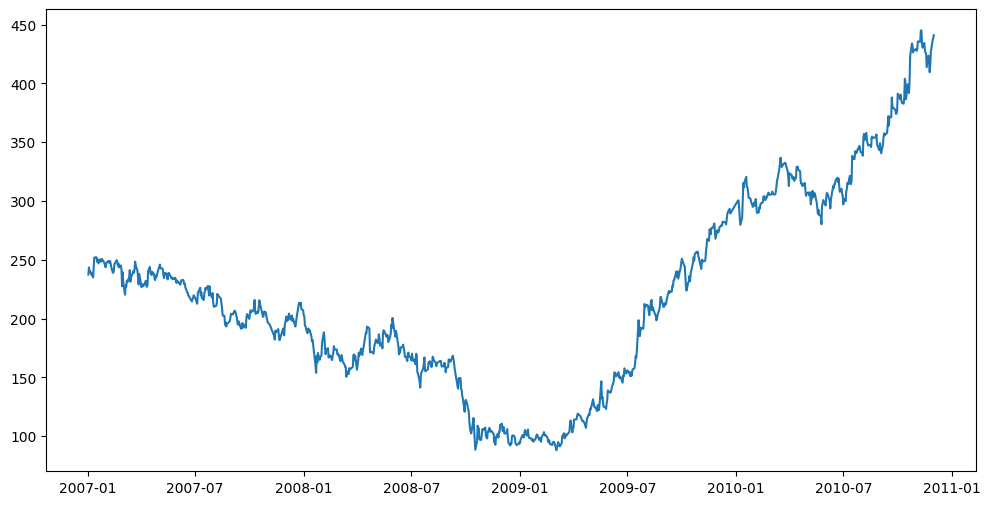

In [12]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')
analysis=df[(df['Date']>='2007-01-01') & (df['Date']<='2010-12-01')]

plt.figure(figsize=(12,6))
plt.plot(analysis['Date'], analysis['Close'])
plt.show()


We can see the 2008-09 slowdown...

it saw major dip in last quarter of 2008 to first quarter of 2009 and then saw a massive resurgence

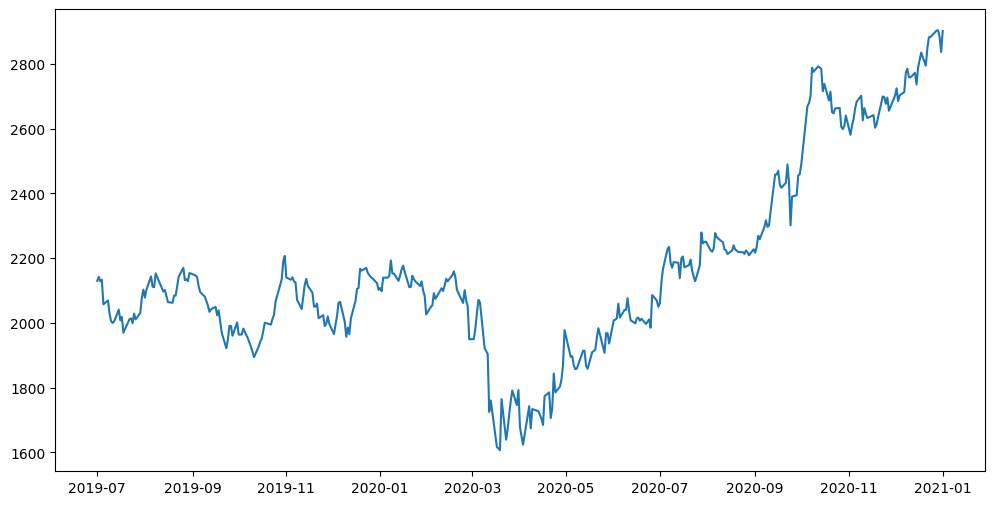

In [25]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')
analysis=df[(df['Date']>='2019-07-01') & (df['Date']<='2021-01-01')]

plt.figure(figsize=(12,6))
plt.plot(analysis['Date'],analysis['Close'])
plt.show()

we can see the instability since sept. 07/2019...

a dip in second quarter of 2020 and then resurgence in last quarter

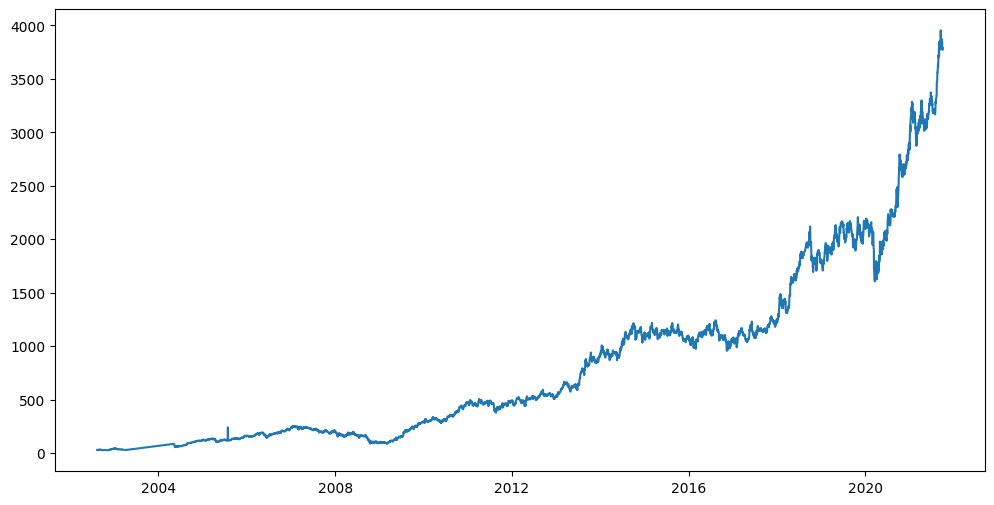

In [18]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')
plt.figure(figsize=(12,6))
plt.plot(df['Date'],df['Close'])

plt.show()



1.An upward movement after 2009 crisis

2.then uptick from 2012 and sharply in 2017 and 2018

3.then after corona crisis stocks have consistenly picked up..

4.two crashes im 2008-09 and 2020 saw stock value dip...

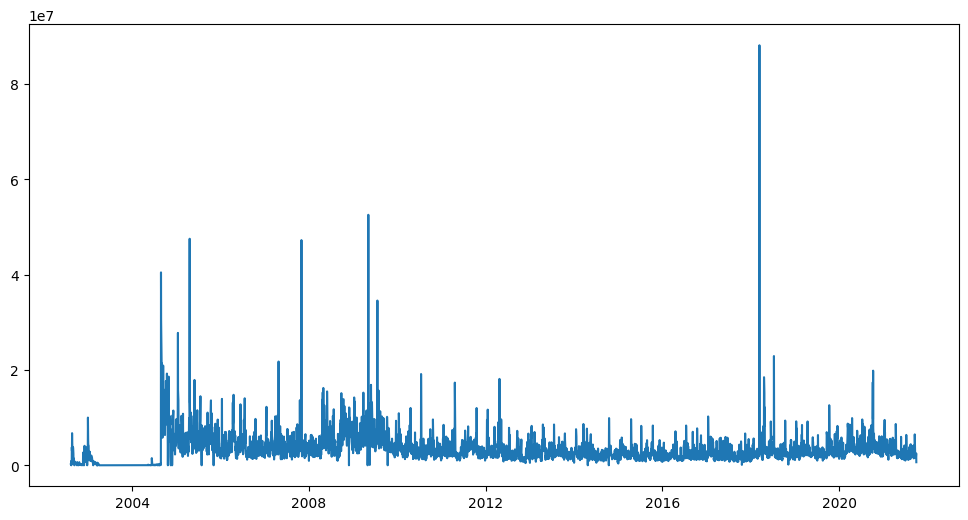

In [26]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')
plt.figure(figsize=(12,6))
plt.plot(df['Date'],df['Volume'])
plt.show()

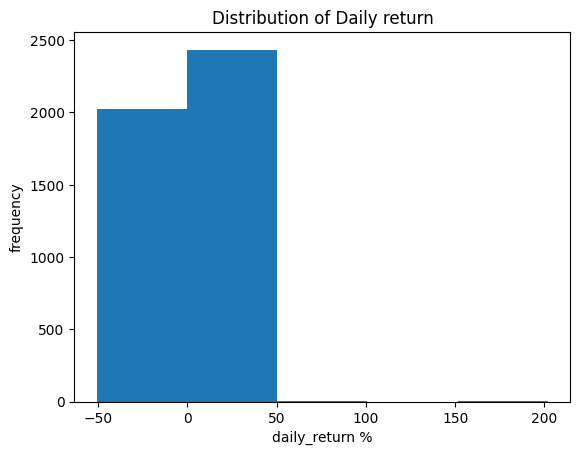

In [15]:
df['daily_return']=df['Close'].pct_change()*100

plt.hist(df['daily_return'],bins=5)
plt.title('Distribution of Daily return')
plt.xlabel('daily_return %')
plt.ylabel('frequency')
plt.show()

so a reasonable variation coz for a large company stock usually don't go beyond -50% to  50% on a day

stock growing 50% are more frequent than declining 50%

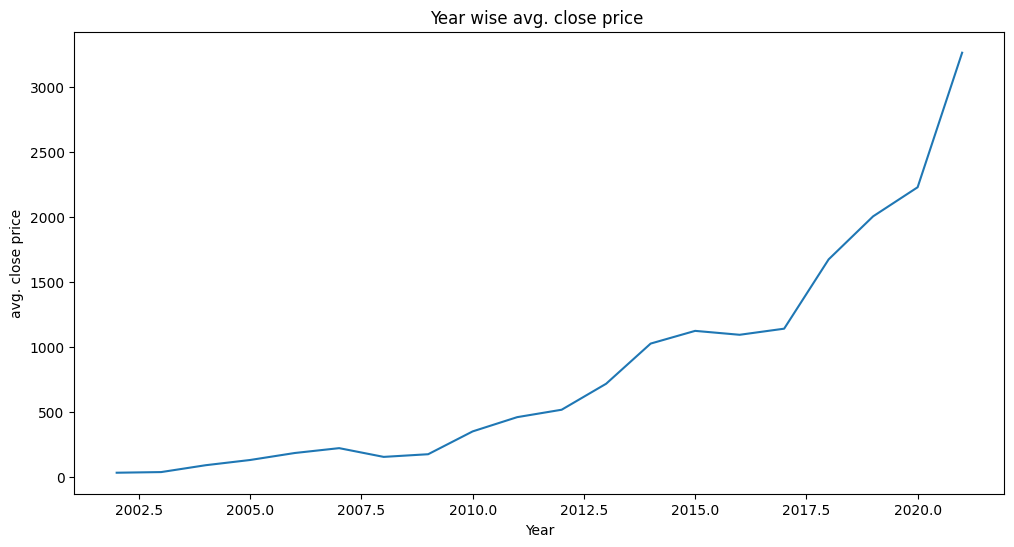

In [23]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')
df['Year']=df['Date'].dt.year

yearly_avg=df.groupby('Year')['Close'].mean()

plt.figure(figsize=(12,6))
plt.plot(yearly_avg.index,yearly_avg.values)
plt.title('Year wise avg. close price ')
plt.xlabel('Year')
plt.ylabel('avg. close price')
plt.show()


            **Year wise avg close price**

A horizontal flow till 2007 and then a sudden drop in 2008-09..

A sudden pickup after 2010 crash and graph moves up with linear flow

A horizontal flow after  2015 for 2 years

almost vertical flow after 2017

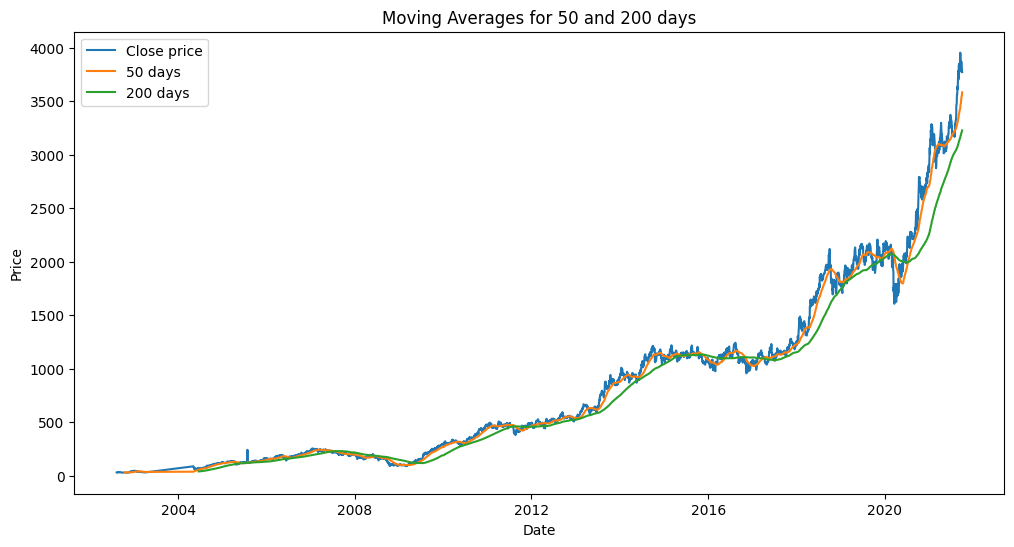

In [28]:
df['MA50']=df['Close'].rolling(window=50).mean()
df['MA200']=df['Close'].rolling(window=200).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Date'],df['Close'],label='Close price')
plt.plot(df['Date'],df['MA50'],label='50 days')
plt.plot(df['Date'],df['MA200'],label='200 days')

plt.title('Moving Averages for 50 and 200 days')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

               ** Moving Averages**

--50 and 200 days seem to similar during normal sitution but differs during crashes

--200 is a more stable one and also during crash of 2008 and 2020

--on a whole line nearly run in sync with each other and with closing day